In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data , columns = diabetes.feature_names)
diabetes_df['target'] = diabetes.target

In [ ]:
diabetes_df.head()
#종속변수는 scaling 예외!!! 절대 안됨~

#s1~s6의 값이 뭔지는 모르겠지만, correlation만 구해보자.




,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


age       0.187889
sex       0.043062
bmi       0.586450
bp        0.441482
s1        0.212022
s2        0.174054
s3       -0.394789
s4        0.430453
s5        0.565883
s6        0.382483
target    1.000000
Name: target, dtype: float64

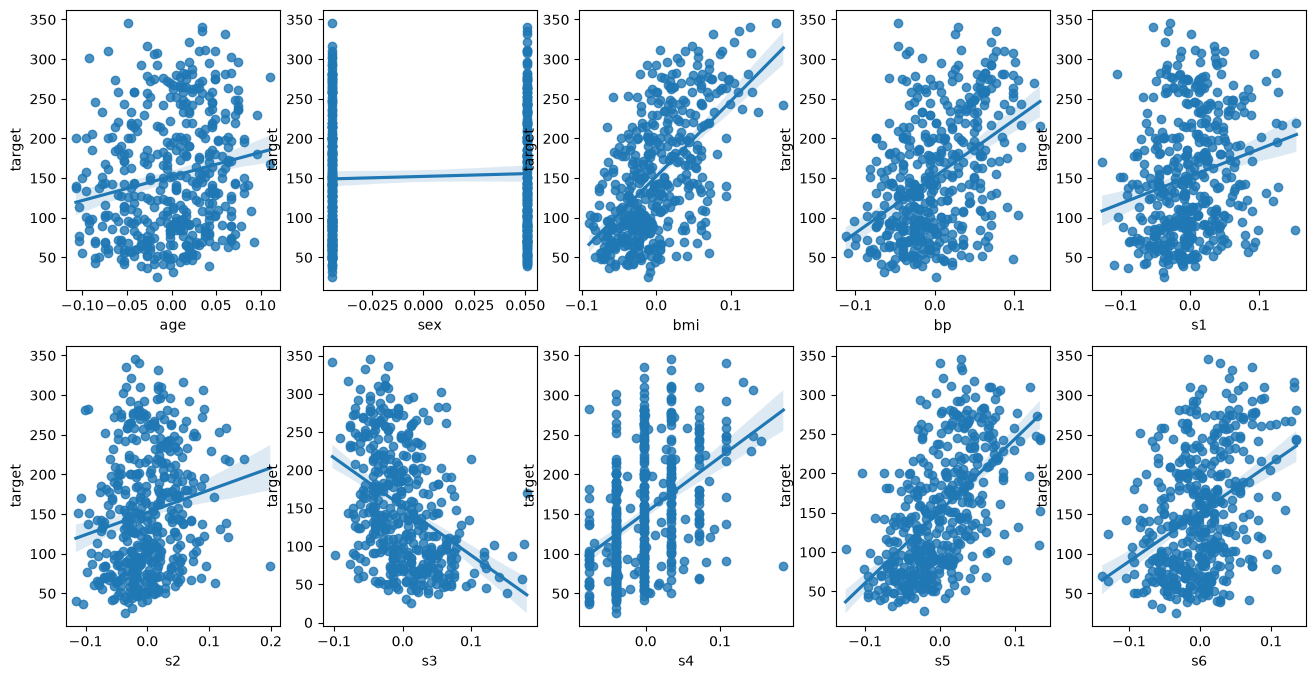

In [12]:
fig, axs = plt.subplots(figsize =(16,8) , ncols =5 , nrows =2)
lm_features = ['age','sex','bmi','bp','s1','s2','s3','s4', 's5', 's6']
for i , feature in enumerate(lm_features):
    row = int(i /5)
    col = i%5
    sns.regplot(x=feature , y='target',data= diabetes_df , ax=axs[row][col])
diabetes_df.corr()['target']

#범주형 독립변수 ,수치형 종속변수는
막대그래프로 비교 해야함.

<Axes: xlabel='sex', ylabel='target'>

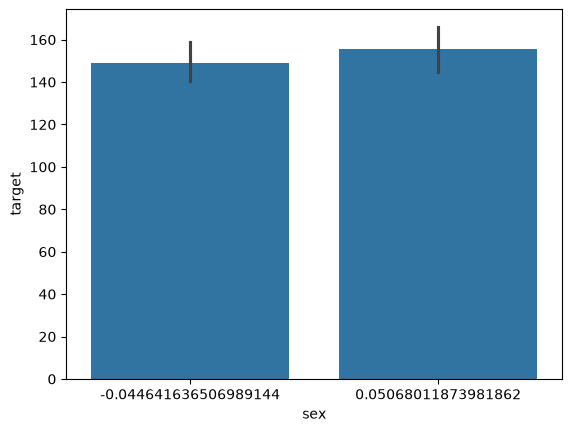

In [ ]:
sns.barplot(x='sex',y='target',data=diabetes_df)

#female, male 글자순?으로 보통 

#whisk가 겹친다 -> sex와 target은 거의 연관이 없다.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X_train, X_test , y_train, y_test= train_test_split(X, y,
test_size=0.2, random_state=156)


In [8]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(353, 10) (89, 10) (353,) (89,)


In [ ]:
#model selection
lr=LinearRegression()

#Learning
lr.fit(X_train,y_train)

#Test
pred=lr.predict(X_test)

#Compute precision score
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)

print(f'MSE: {mse:.3f}, RMSE:{rmse:.3f}')
print(f'Variance: {r2_score(y_test,pred):.3f}')

#variance score는  상대적인 값이기 때문에,
#몇점 이상이 좋은 학습이라고 정의할 수가 없다.

#1에 가까울 수록 좋은 학습 지표.
#대신 다른 모델과 점수비교 ok- > 더 좋은 학습 모델
#단, 평가방식은 동일해야함 (mse, mae)
#train test data,test size 비율은 전부 동일 해야함.


#Scale 방식 , encoding 방식 변화 -> 학습 방식의 변화.
#학습 데이터,트레인 데이터는 차이없음.



MSE: 3049.651, RMSE:55.224
Variance: 0.414


In [11]:
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]
X=X.drop('sex',axis=1)

X_train, X_test , y_train, y_test= train_test_split(X, y,
test_size=0.2, random_state=156)


#model selection
lr=LinearRegression()

#Learning
lr.fit(X_train,y_train)

#Test
pred=lr.predict(X_test)

#Compute precision score
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)


print(f'MSE: {mse:.3f}, RMSE:{rmse:.3f}')
print(f'Variance: {r2_score(y_test,pred):.3f}')

MSE: 3106.928, RMSE:55.740
Variance: 0.403


성별과 당뇨 수치는 큰 관련이 없어보였는데.

여러 Features들이 서로 연관이 되어있어서,
당뇨병 수치를 예측하는데 어느정도 영향을 미칠 수 있다.

실제 서비스 구현=우리가 가지고 있는 데이터를 기반으로 하는것이 좋다.(스케일링,인코딩,암호화 되지 않은 것.)


In [14]:
lr.intercept_

lr.coef_

array([   2.63765833,  544.84177305,  264.0257416 , -986.04663756,
        677.61647966,  190.98068077,   28.49743525,  933.81838384,
         51.43790726])

In [ ]:
#예측시 2차원 배열 필요.
#인덱싱으로 series를 배열로 만드는 방법 : 리스트 인덱싱 이중으로 사용하기.
one_data=X_test.iloc[[10]]
one_data
lr.predict(one_data)

array([93.71525393])

In [ ]:
A=[   2.63765833,  544.84177305,  264.0257416 , -986.04663756,
        677.61647966,  190.98068077,   28.49743525,  933.81838384,
         51.43790726]

one_data=X_test.iloc[10]

#예측한 weights와 intercept, x데이터 기준으로 target value를 구함.
#모델이 하는 것과 동일.
sum(one_data*A)+lr.intercept_

np.float64(93.71525393084197)

In [ ]:
lr=LinearRegression()

In [42]:
from sklearn.model_selection import cross_val_score
lr= LinearRegression()


y=diabetes_df.iloc[:,-1]
x=diabetes_df.iloc[:,:-1]

score=cross_val_score(lr,x,y,scoring='neg_root_mean_squared_error',cv=5)
score

array([-52.72497937, -55.03486476, -56.90068179, -54.85204179,
       -53.94638716])

InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'average_precision', 'roc_auc_ovr', 'precision_weighted', 'roc_auc', 'f1_weighted', 'normalized_mutual_info_score', 'v_measure_score', 'roc_auc_ovo_weighted', 'f1_samples', 'neg_negative_likelihood_ratio', 'neg_mean_poisson_deviance', 'neg_mean_absolute_error', 'd2_log_loss_score', 'recall_weighted', 'jaccard_micro', 'precision_macro', 'precision_samples', 'r2', 'recall_micro', 'd2_absolute_error_score', 'f1_micro', 'roc_auc_ovr_weighted', 'jaccard', 'neg_log_loss', 'balanced_accuracy', 'accuracy', 'fowlkes_mallows_score', 'roc_auc_ovo', 'homogeneity_score', 'neg_max_error', 'neg_root_mean_squared_log_error', 'neg_root_mean_squared_error', 'adjusted_mutual_info_score', 'top_k_accuracy', 'jaccard_samples', 'jaccard_macro', 'precision', 'recall_samples', 'neg_mean_squared_log_error', 'rand_score', 'neg_mean_squared_error', 'neg_brier_score', 'matthews_corrcoef', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'completeness_score', 'neg_median_absolute_error', 'd2_brier_score', 'recall', 'precision_micro', 'recall_macro', 'f1_macro', 'mutual_info_score', 'jaccard_weighted', 'explained_variance', 'f1', 'positive_likelihood_ratio', 'adjusted_rand_score'}, a callable or None. Got 'mean_squared_error' instead.

loss=작을 수록 좋은
score=값이 클 수록 좋은.

평가지표의 종류에 따라. 

In [41]:
score_mean=np.mean(score*-1)
score_std=np.std(score*-1)

print(score_mean-score_std,score_mean+score_std)

53.317268997129666 56.06631294838619


In [ ]:
from  sklearn.preprocessing import PolynomialFeatures
import numpy as np

X=np.arange(4).reshape(2,2)

print(X)
poly=PolynomialFeatures(include_bias=False,degree=3)
poly_ftr=poly.fit_transform(X)


[[0 1]
 [2 3]]


array([[ 0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.],
       [ 2.,  3.,  4.,  6.,  9.,  8., 12., 18., 27.]])

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
diabetes=  load_diabetes()
diabetes_df = pd.DataFrame(diabetes.data , columns = diabetes.feature_names)
diabetes_df['target'] = diabetes.target
y = diabetes_df.iloc[:, -1]
X = diabetes_df.iloc[:, :-1]

poly=PolynomialFeatures(degree=2,include_bias=False)
X_poly=poly.fit_transform(X)
print(poly.get_feature_names_out(input_features=X.columns))



X_train, X_test , y_train, y_test= train_test_split(X_poly, y,
test_size=0.2, random_state=156)


#model selection
lr=LinearRegression()

#Learning
lr.fit(X_train,y_train)

#Test
pred=lr.predict(X_test)

#Compute precision score
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)



print(f'MSE: {mse:.3f}, RMSE:{rmse:.3f}')
print(f'Variance: {r2_score(y_test,pred):.3f}')

['age' 'sex' 'bmi' 'bp' 's1' 's2' 's3' 's4' 's5' 's6' 'age^2' 'age sex'
 'age bmi' 'age bp' 'age s1' 'age s2' 'age s3' 'age s4' 'age s5' 'age s6'
 'sex^2' 'sex bmi' 'sex bp' 'sex s1' 'sex s2' 'sex s3' 'sex s4' 'sex s5'
 'sex s6' 'bmi^2' 'bmi bp' 'bmi s1' 'bmi s2' 'bmi s3' 'bmi s4' 'bmi s5'
 'bmi s6' 'bp^2' 'bp s1' 'bp s2' 'bp s3' 'bp s4' 'bp s5' 'bp s6' 's1^2'
 's1 s2' 's1 s3' 's1 s4' 's1 s5' 's1 s6' 's2^2' 's2 s3' 's2 s4' 's2 s5'
 's2 s6' 's3^2' 's3 s4' 's3 s5' 's3 s6' 's4^2' 's4 s5' 's4 s6' 's5^2'
 's5 s6' 's6^2']
MSE: 3149.806, RMSE:56.123
Variance: 0.395


In [81]:
np.random.rand(30)

array([0.70220004, 0.49060761, 0.70257249, 0.87533009, 0.55454774,
       0.33662071, 0.13523048, 0.77204675, 0.75233332, 0.06174154,
       0.54780542, 0.92105995, 0.77148252, 0.31625324, 0.65780428,
       0.61548435, 0.34450966, 0.93658602, 0.51256771, 0.92592494,
       0.07010183, 0.68415247, 0.18379481, 0.14743118, 0.3860739 ,
       0.1149381 , 0.64709132, 0.93870355, 0.74530062, 0.14940305])

<Axes: xlabel='Density'>

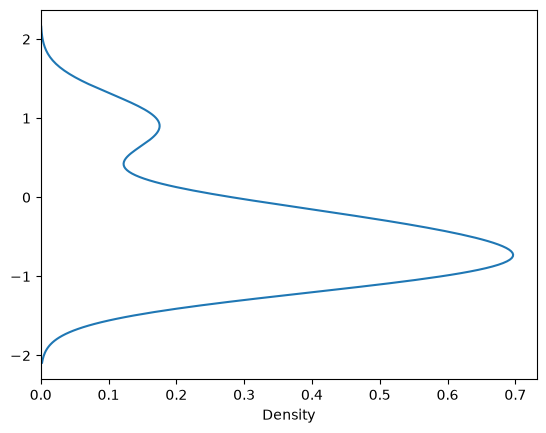

In [33]:
import seaborn as sb
import numpy as np
def true_fun(X):
    return np.cos(1.5*np.pi*X)

np.random.seed(0)
n_samples=30

X=np.sort(np.random.rand(n_samples))
y=true_fun(X) + np.random.randn(n_samples)*0.1

sb.kdeplot(y=y)

[0.0202184  0.07103606 0.0871293  0.11827443 0.14335329 0.38344152
 0.41466194 0.4236548  0.43758721 0.46147936 0.52184832 0.52889492
 0.54488318 0.5488135  0.56804456 0.60276338 0.63992102 0.64589411
 0.71518937 0.77815675 0.78052918 0.79172504 0.79915856 0.83261985
 0.87001215 0.891773   0.92559664 0.94466892 0.96366276 0.97861834]

Degree1 회귀계수는
[-1.61]
입니다.
MSE는0.4077289625098685입니다.


NameError: name 'X_train' is not defined

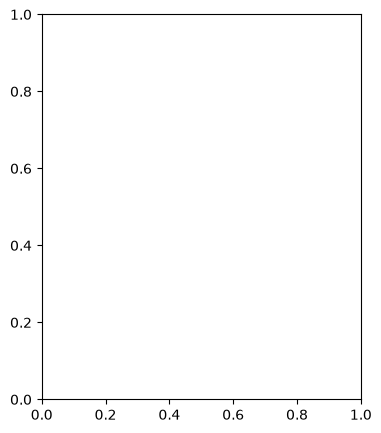

In [35]:
import matplotlib.pyplot as plt
from  sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i+ 1)
    polynomial_features= PolynomialFeatures(degree=degrees[i], include_bias=False)
    
    #Model Selection
    lr_reg= LinearRegression()
    print(X)
    X_poly= polynomial_features.fit_transform(X.reshape(-1,1), y)
    lr_reg.fit(X_poly, y)
    scores = cross_val_score(lr_reg, X_poly, y, scoring='neg_mean_squared_error', cv=10)
    coeff= lr_reg.coef_
    print(f'\nDegree{degrees[i]} 회귀계수는\n{np.round(coeff, 2)}\n입니다.')
    print(f'MSE는{-1 * np.mean(scores)}입니다.')
    X_test= np.linspace(0, 1, 100).reshape(-1, 1)
    X_test_poly= polynomial_features.transform(X_test)
    pred = lr_reg.predict(X_train)
    plt.plot(X_test, pred, label = 'Model')
    plt.plot(X_test, true_fun(X_test), '--', label='True Function')
    plt.scatter(X, y, edgecolors='b', s = 20, label = 'Samples')
    plt.xlabel('x');plt.ylabel('y'); plt.xlim((0,1)); plt.ylim((-2, 2)); plt.legend()
    plt.title(f'Degree{degrees[i]}\nMSE={-scores.mean():.2f}')
plt.show()


In [ ]:
# 과소/과대적합 케이스 코드 테스트가 필요하다.

In [60]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge


poly=PolynomialFeatures(degree=1,include_bias=False)
X_poly= polynomial_features.fit_transform(X, y)
lr_reg.fit(X_poly, y)

X_train, X_test , y_train, y_test= train_test_split(X_poly, y,
test_size=0.2, random_state=156)

ridge=Ridge(alpha=0)
ridge=LinearRegression()

ridge.fit(X_train,y_train)
pred=ridge.predict(X_test)
pred_train=ridge.predict(X_train)

mse=mean_squared_error(y_test,pred)
mse_train=mean_squared_error(y_train,pred_train)

print(mse,mse_train)

3049.651251926588 2829.7198153252625


과소적합: Ridge alpha level을 낮추면 효율이 더 좋아짐.

과적합: alpha level을 낮추면 효율이 더 나빠짐.

alpha level=0이면  Linear Regression과 동일하다.



# Ridge
L2 규제를 사용한다
회귀 계수를 0에 가깝게 만들지만, 0으로 만들진 않음.
독립변수의 중요도를 낮춘다.

? 다중공선성 문제? 가 있을때 연관이 강한 독립변수의 
weight를 우선적으로 줄여줌.
-> 어떤 방식으로 연관이 강한 독립변수의 weight를 줄이는 걸까?

[다중공선성 문제]
-> 독립변수가 독립적이지 않고, x1,x2 상관계수가 높은 경우.
-> 근데 그게 왜 예측에 방해가 되는걸까?(숙제)

# Lasso
L1 규제를 사용한다.
회귀 계수를 0으로 만들어서, 중요한 독립변수만 선택한다.
필요없는 독립변수를 제외시킴.

-> 어떤 독립변수를 먼저 제외 시키는 걸까?(제외시키는 순서나
원리가 궁금하다.)

독립변수가 너무 많을 때 '수'를 줄여서 경량화가 필요한 경우.

이 둘을 쓰는 이유는, 과도한 학습 데이터 학습으로
생기는 과적합 문제를 예방하기 위함이다.

# Elastic Net
= Ridge+Lasso
규제강도 조절 가능.

Ridge와 Lasso의 방해 비율을 선택적으로 조정할 수 있다.




In [ ]:
from sklearn.linear_model import ElasticNet

#alpha=lambda l1: alpha value
#l1=lasso, l2=ridge

#Grid search로 최적의 alpha와 beta 구해보기 (숙제.)
#->보통은 l1, l2중 1개만 사용.
ElasticNet(alpha=0.1,l1_ratio=0.5)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [76]:
from sklearn.linear_model import SGDRegressor
alphas=[0,0.001,0.1,1,10]

for alpha in alphas:
    sgd_reg=SGDRegressor(alpha=alpha,max_iter=10000,penalty='l2')
    neg_mse_scores=cross_val_score(sgd_reg,X,y,
                                   scoring="neg_mean_squared_error",cv=5)
    avg_rmse=np.mean(np.sqrt(-1*neg_mse_scores))
    print(avg_rmse)

54.90186250110874
56.48212665905063
75.08155620084226
77.01620065806554
77.24383276052853


SGDRegressor

max_iter= 1000
1000번까지만 하고 멈춰라. != 1000번 '학습했다'가 아님.

다만 최소값에 수렴하면서 학습 성과가 좋아짐.

SGD가 왜 속도가 빠른 걸까?

In [ ]:
#Ridge(solver=??)

#RSS를 결정하는 방법을 명시.
# {‘auto’, ‘svd’, ‘cholesky’, ‘lsqr’, ‘sparse_cg’, ‘sag’, ‘saga’, ‘lbfgs’}, default=’auto’

In [78]:
from sklearn.tree import DecisionTreeRegressor


dt_reg=DecisionTreeRegressor(random_state=0,max_depth=4)
dt_reg.fit(X_train,y_train)
pred= dt_reg.predict(X_test)

mean_squared_error(pred,y_test)

3843.214385224017

Decision Tree를 왜 쓰지?

RandomForestRegressor = decision tree + ensemble


What is an Ensemble?

Combination of multiple models to improve predictive performance.

: collective learners returns great result compared to individual learner.

### Voting

### Bagging

### Boosting
1. Individual Learning
2. Correct miscalssified data instances.
3. Repeat this process

### Stacking

https://www.ibm.com/think/topics/ensemble-learning

+ XGBoost,
LightGBM
CatBoost

In [86]:
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor

ada_reg=RandomForestRegressor(n_estimators=500,max_depth=400)
ada_reg.fit(X_train,y_train)
pred= ada_reg.predict(X_test)

mean_squared_error(pred,y_test)


3650.82078952809

# 머신러닝 예측 실습 순서

#0. 프로젝트 기획
무엇을 예측할 것인가?

1. 데이터 정의
목표를 위해 필요한 데이터를 어떻게 얻을 것인지.
수집방법, 컬럼 종류 확인., 

2. 데이터 준비

3. 데이터 전처리
4. 데이터 분석
결측치,이상치, 타입 확인., 변수정의, 상관관계 확인 및 가설 수립, 

5. 모델 학습/예측/평가

6. 머신러닝 성능 향상 방법 찾기
3번부터 다른 방법으로 해보기.
